# Experiment: ResNet50 Baseline

**Student ID:** 25509225  
**Experiment:** Baseline - Standard ResNet50 with single FC layer (2048→10)  
**Purpose:** Establish baseline performance for comparison with customized models.

## Cell 1: Load Modules

In [17]:
%run ./ResNet50_modules.ipynb

Using device: cuda
GPU: Tesla T4
Memory: 14.6 GB
✓ ResNet50Classifier defined
✓ TrainingConfig dataclass defined
✓ ClassificationTrainer defined
✓ Data loading utilities defined
✓ ClassificationEvaluator defined

✓ All modules loaded successfully!


## Cell 2: Configuration

In [18]:
# === Model Configuration ===
BASELINE_CONFIG = {
    'num_classes': 10,
    'dropout_rate': 0.5,
    'pretrained': True,
    'fc_hidden_dims': None,
    'use_batch_norm': True,
    'modify_backbone': False
}

# === Training Configuration ===
TRAINING_CONFIG_BASELINE = TrainingConfig(
    learning_rate=5e-4,
    weight_decay=5e-4,
    epochs=200,
    use_warmup=True,
    warmup_epochs=10,
    use_scheduler=True,
    scheduler_patience=7,
    scheduler_factor=0.5,
    use_early_stopping=True,
    early_stopping_patience=50,
    label_smoothing=0.1,
    description='Baseline training'
)

# === Experiment Settings ===
STUDENT_ID = "25509225"
DATA_ROOT = f"/home/sagemaker-user/CNN_A2/data/{STUDENT_ID}/Image_Classification/split_dataset"

BATCH_SIZE = 16
AUGMENTATION_TYPE = 'none'  # Can be changed to 'standard' or 'enhanced'
USE_PRETRAINED = False       # Can be changed to False

output_dir = Path(f'outputs/classification_baseline')
output_dir.mkdir(parents=True, exist_ok=True)

print("=" * 80)
print("EXPERIMENT: ResNet50 Baseline")
print("=" * 80)
print(f'\nConfiguration:')
print(f'  Data Root: {DATA_ROOT}')
print(f'  Batch Size: {BATCH_SIZE}')
print(f'  Augmentation: {AUGMENTATION_TYPE}')
print(f'  Pretrained: {USE_PRETRAINED}')
print(f'  Output Dir: {output_dir}')

EXPERIMENT: ResNet50 Baseline

Configuration:
  Data Root: /home/sagemaker-user/CNN_A2/data/25509225/Image_Classification/split_dataset
  Batch Size: 16
  Augmentation: none
  Pretrained: False
  Output Dir: outputs/classification_baseline


## Cell 3: Step 1 - Load Data

In [19]:
print("\n[1/5] Loading data...")
train_loader, val_loader, test_loader, class_names = create_classification_dataloaders(
    DATA_ROOT, 
    batch_size=BATCH_SIZE, 
    augmentation_type=AUGMENTATION_TYPE
)
print(f'Classes: {class_names}')
print(f'Train: {len(train_loader.dataset)}, Val: {len(val_loader.dataset)}, Test: {len(test_loader.dataset)}')

aug_descriptions = {
    'none': 'No augmentation (basic preprocessing only)',
    'standard': 'Standard (Rotation 15°, ColorJitter 0.2)',
    'enhanced': 'Enhanced (Rotation 20°, ColorJitter 0.3+hue, RandomAffine)'
}
print(f'Data augmentation: {aug_descriptions[AUGMENTATION_TYPE]}')


[1/5] Loading data...
Classes: ['CRESTED KINGFISHER', 'CROW', 'EASTERN MEADOWLARK', 'FAIRY BLUEBIRD', 'HARLEQUIN QUAIL', 'LAUGHING GULL', 'PALILA', 'PARADISE TANAGER', 'RAINBOW LORIKEET', 'TOWNSENDS WARBLER']
Train: 1109, Val: 231, Test: 249
Data augmentation: No augmentation (basic preprocessing only)


## Cell 4: Step 2 - Initialize Model

In [20]:
print("\n[2/5] Initializing model...")

model_config = BASELINE_CONFIG.copy()
model_config['pretrained'] = USE_PRETRAINED

if model_config['pretrained']:
    print('Architecture: Standard ResNet50 with ALL layers trainable (NO freezing)')
    print('Pretrained: YES (ImageNet weights)')
else:
    print('Architecture: Standard ResNet50 with ALL layers trainable (NO freezing)')
    print('Pretrained: NO (Training from scratch)')

model = ResNet50Classifier(**model_config)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params: {total_params:,}, Trainable: {trainable_params:,} ({trainable_params/total_params*100:.1f}%)')

# Print model summary
trainer_temp = ClassificationTrainer(model, config=TRAINING_CONFIG_BASELINE)
trainer_temp.print_model_summary()


[2/5] Initializing model...
Architecture: Standard ResNet50 with ALL layers trainable (NO freezing)
Pretrained: NO (Training from scratch)
Total params: 23,528,522, Trainable: 23,528,522 (100.0%)

MODEL ARCHITECTURE SUMMARY

Layer Name                     Input Shape          Output Shape         Params       Trainable   
--------------------------------------------------------------------------------
Conv2d                         [2, 3, 224, 224]     [2, 64, 112, 112]    9,408        9,408       
BatchNorm2d                    [2, 64, 112, 112]    [2, 64, 112, 112]    128          128         
ReLU                           [2, 64, 112, 112]    [2, 64, 112, 112]    0            0           
MaxPool2d                      [2, 64, 112, 112]    [2, 64, 56, 56]      0            0           
Conv2d                         [2, 64, 56, 56]      [2, 64, 56, 56]      4,096        4,096       
BatchNorm2d                    [2, 64, 56, 56]      [2, 64, 56, 56]      128          128         


## Cell 5: Step 3 - Train

In [21]:
print("\n[3/5] Training...")
trainer = trainer_temp  # Reuse trainer from Cell 4
criterion = torch.nn.CrossEntropyLoss(label_smoothing=TRAINING_CONFIG_BASELINE.label_smoothing)

history = trainer.train(
    train_loader, 
    val_loader, 
    criterion,
    str(output_dir)  # Only saves best_model.pth
)
print(f'Best Val Acc: {trainer.best_val_acc:.4f}')


[3/5] Training...

Training: Baseline training
  Epochs: 200, LR: 0.0005, Weight Decay: 0.0005
  Early Stopping: Enabled (patience=50)



Epoch 1: 100%|██████████| 70/70 [00:05<00:00, 13.69it/s, loss=2.4466, acc=12.62%]


Epoch 1/200 | Train Loss: 2.4013 | Train Acc: 0.1262 | Val Loss: 2.2083 | Val Acc: 0.2208
  ✓ Best model saved (Val Acc: 0.2208)


Epoch 2: 100%|██████████| 70/70 [00:05<00:00, 13.59it/s, loss=1.5334, acc=28.94%]


Epoch 2/200 | Train Loss: 2.0937 | Train Acc: 0.2894 | Val Loss: 1.9561 | Val Acc: 0.4113
  ✓ Best model saved (Val Acc: 0.4113)


...

Epoch 129/200 | Train Loss: 0.5181 | Train Acc: 1.0000 | Val Loss: 0.7239 | Val Acc: 0.9351


Epoch 130: 100%|██████████| 70/70 [00:05<00:00, 13.23it/s, loss=0.7165, acc=100.00%]


Epoch 130/200 | Train Loss: 0.5194 | Train Acc: 1.0000 | Val Loss: 0.7073 | Val Acc: 0.9524


Epoch 131: 100%|██████████| 70/70 [00:05<00:00, 13.69it/s, loss=0.5896, acc=100.00%]


Epoch 131/200 | Train Loss: 0.5185 | Train Acc: 1.0000 | Val Loss: 0.7068 | Val Acc: 0.9394

Early stopping at epoch 131
Best Val Acc: 0.9524


## Cell 6: Load Best Model

In [22]:
print("\nLoading best model for evaluation...")
best_model_path = output_dir / 'best_model.pth'
if best_model_path.exists():
    # Use weights_only=False because checkpoint contains custom TrainingConfig object
    checkpoint = torch.load(best_model_path, map_location='cpu', weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    model = model.to(trainer.device)
    print(f'✓ Loaded best model from epoch {checkpoint["epoch"]} (Val Acc: {checkpoint["val_acc"]:.4f})')
else:
    print('Warning: Best model checkpoint not found, using current model')


Loading best model for evaluation...
✓ Loaded best model from epoch 80 (Val Acc: 0.9524)


## Cell 7: Step 4 - Evaluate

In [23]:
print("\n[4/5] Evaluating on test set...")
evaluator = ClassificationEvaluator(class_names)
metrics = evaluator.evaluate(model, test_loader)  # No output_dir parameter

print("\n=== Test Set Metrics ===")
print(f"Accuracy: {metrics['accuracy']:.4f}")
print(f"Precision (weighted): {metrics['precision_weighted']:.4f}")
print(f"Recall (weighted): {metrics['recall_weighted']:.4f}")
print(f"F1 (weighted): {metrics['f1_weighted']:.4f}")
print(f"\nPrecision (macro): {metrics['precision_macro']:.4f}")
print(f"Recall (macro): {metrics['recall_macro']:.4f}")
print(f"F1 (macro): {metrics['f1_macro']:.4f}")


[4/5] Evaluating on test set...
MODEL EVALUATION


Evaluating: 100%|██████████| 16/16 [00:00<00:00, 16.23it/s]


Overall Metrics:
  Accuracy: 0.9317
  Precision (weighted): 0.9319
  Recall (weighted): 0.9317
  F1-Score (weighted): 0.9313
  Precision (macro): 0.9329
  Recall (macro): 0.9320
  F1-Score (macro): 0.9319

Per-Class Metrics:
  CRESTED KINGFISHER: P=1.0000 R=1.0000 F1=1.0000
  CROW: P=0.9200 R=0.9200 F1=0.9200
  EASTERN MEADOWLARK: P=0.9286 R=0.9630 F1=0.9455
  FAIRY BLUEBIRD: P=0.9545 R=0.8750 F1=0.9130
  HARLEQUIN QUAIL: P=0.9545 R=0.9545 F1=0.9545
  LAUGHING GULL: P=0.9000 R=0.9643 F1=0.9310
  PALILA: P=0.9167 R=0.9167 F1=0.9167
  PARADISE TANAGER: P=0.9167 R=0.8462 F1=0.8800
  RAINBOW LORIKEET: P=0.9583 R=1.0000 F1=0.9787
  TOWNSENDS WARBLER: P=0.8800 R=0.8800 F1=0.8800

Confusion Matrix:
[[25  0  0  0  0  0  0  0  0  0]
 [ 0 23  0  0  0  2  0  0  0  0]
 [ 0  0 26  0  0  0  0  0  0  1]
 [ 0  1  0 21  0  0  0  2  0  0]
 [ 0  0  1  0 21  0  0  0  0  0]
 [ 0  1  0  0  0 27  0  0  0  0]
 [ 0  0  0  0  1  0 22  0  0  1]
 [ 0  0  0  1  0  1  1 22  0  1]
 [ 0  0  0  0  0  0  0  0 23  0]
 

## Cell 8: Display Confusion Matrix


=== Confusion Matrix ===


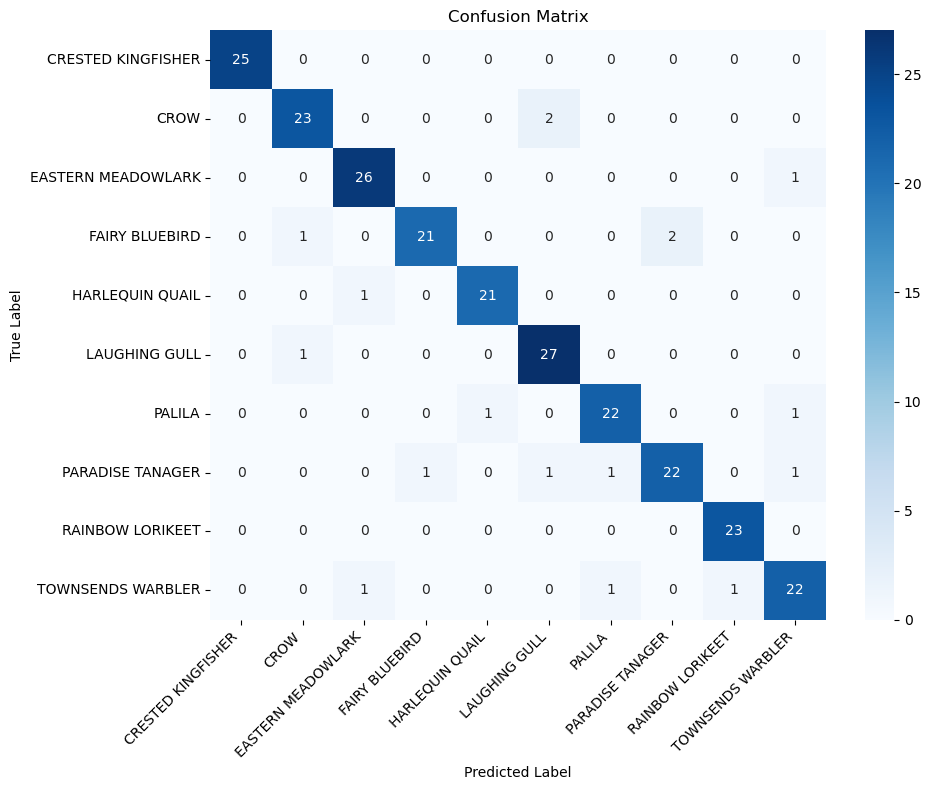

In [24]:
print("\n=== Confusion Matrix ===")
fig, ax = plt.subplots(figsize=(10, 8))
cm_array = metrics['confusion_matrix']
sns.heatmap(cm_array, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Cell 9: Step 5 - Display Training Curves


[5/5] Training History Analysis


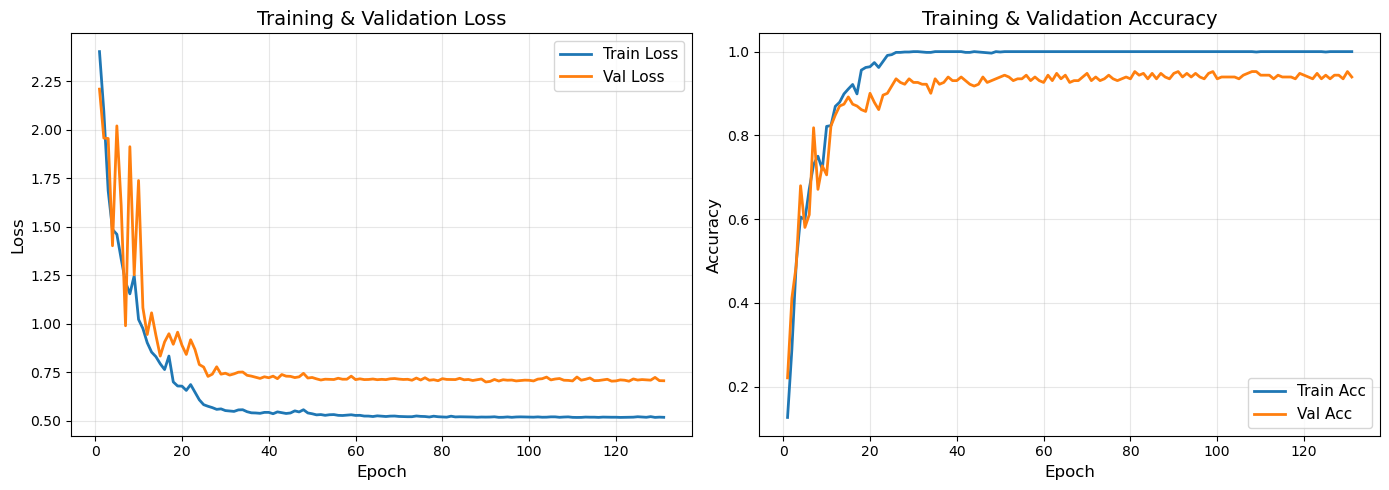

In [25]:
print("\n[5/5] Training History Analysis")

# history is a dict with 'history' key containing a list of dicts
training_history = history['history']  # This is a list

# Extract data from the list of dictionaries
epochs = [h['epoch'] for h in training_history]
train_losses = [h['train_loss'] for h in training_history]
val_losses = [h['val_loss'] for h in training_history]
train_accs = [h['train_acc'] for h in training_history]
val_accs = [h['val_acc'] for h in training_history]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(epochs, train_losses, label='Train Loss', linewidth=2)
axes[0].plot(epochs, val_losses, label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training & Validation Loss', fontsize=14)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Accuracy curve
axes[1].plot(epochs, train_accs, label='Train Acc', linewidth=2)
axes[1].plot(epochs, val_accs, label='Val Acc', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Training & Validation Accuracy', fontsize=14)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Cell 10: Overfitting Analysis

In [26]:
print("\n=== Overfitting Analysis ===")
analysis = evaluator.analyze_overfitting(history['history'])
print(f"Pattern: {analysis['pattern']}")
print(f"Train-Val Accuracy Gap: {analysis['gap']:.4f}")
print(f"Recommendation: {analysis['recommendation']}")


=== Overfitting Analysis ===
Pattern: good_fit
Train-Val Accuracy Gap: 0.0571
Recommendation: Model performance is acceptable.


## Cell 11: Final Summary

In [27]:
print("\n" + "=" * 80)
print("EXPERIMENT COMPLETED")
print("=" * 80)
print(f"\nExperiment: ResNet50 Baseline")
print(f"Architecture: Standard ResNet50 with single FC layer (2048→10)")
print(f"Pretrained: {model_config['pretrained']}")
print(f"Data Augmentation: {AUGMENTATION_TYPE}")
print(f"Best Val Accuracy: {trainer.best_val_acc:.4f}")
print(f"Test Accuracy: {metrics['accuracy']:.4f}")
print(f"Total Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")
print(f"\nResults saved to: {output_dir}")
print(f"  - best_model.pth ✓")


EXPERIMENT COMPLETED

Experiment: ResNet50 Baseline
Architecture: Standard ResNet50 with single FC layer (2048→10)
Pretrained: False
Data Augmentation: none
Best Val Accuracy: 0.9524
Test Accuracy: 0.9317
Total Parameters: 23,528,522
Trainable Parameters: 23,528,522

Results saved to: outputs/classification_baseline
  - best_model.pth ✓
